# SBERT Sentence Analysis

## 1. Preparations

### 1.1 Read Data
The sentence data were preprocessed (see preprocessing.ipynb)
In the dataframe:  
- "sentence" = preprocessed sentences with placeholders of anonymized information, **used for the analysis**
- "clean_sentence" = proprocessed sentences with placeholders removed,  
- "translated_sentence" = translated from "sentence" column to English with translate.ipynb

In [1]:
# first install numpy=1.26.4 before installing pandas and other packages
# %pip install numpy=1.26.4
# %pip install pandas openpyxl

import pandas as pd
# read the sentence data 
df = pd.read_excel("/workspace/persistent/mijnidbcoachnlp/data/analysis_data/sentence_data_for_analysis.xlsx", index_col=0)
sentences = df["sentence"].to_list()

# check the df head
df.head()

,message_id,sentence,clean_sentence,sentence_id,translated_sentence
0,1,"Geachte ibd groep, Is mijn uitslag al binnen ...","ibd groep, Is mijn uitslag al binnen van de b...",1,"Dear Ibd group, has my results come back from ..."
1,3,Vorige week is door [ZIEKENHUIS] [LOCATIE] mij...,Vorige week is door mijn ontlasting onderzoc...,2,Last week my stool was examined by [SIGHSHOUSE...
2,3,Graag zou ik de uitkomst hiervan vernemen.,Graag zou ik de uitkomst hiervan vernemen.,3,I would like to hear the outcome of this.
3,4,bloed in de ontlasting wordt steeds meer en st...,bloed in de ontlasting wordt steeds meer en st...,4,blood in the stool is becoming more and more f...
4,4,Ligt dit aan de medicatie?,Ligt dit aan de medicatie?,5,Is this because of the medication?


In [2]:
# check input size
len_data = len(sentences)
print(f"data size: {len_data}")

data size: 41119


In [3]:
### Importing the list of Dutch stopwords (note that there are customized dutch words in there)

with open('/workspace/persistent/mijnidbcoachnlp/data/analysis_data/stopwords_extended.txt', 'r') as file:
    lines = [line.strip() for line in file.readlines()]

dutch_stopwords = lines

In [4]:
# %pip install gensim

import pickle
from gensim.corpora import Dictionary

# Load the tokenized texts
with open("/workspace/persistent/mijnidbcoachnlp/data/tokens/tokenized_sentences.pkl", "rb") as f:
    tokenized_texts = pickle.load(f)

dictionary = Dictionary(tokenized_texts)

### 1.2 Embed the lists of sentences (Commented Out)
In this section, we embed the sentence data with five differen sentence transformer models available on Hugging Face. Only run once.

In [5]:
# %pip install sentence_transformers

from sentence_transformers import SentenceTransformer
from tqdm.autonotebook import tqdm  
import numpy as np
import sentence_transformers.util
import os 
import numpy as np

def embed_and_save(docs, embedding_model, save_path):
    """Generate embeddings for documents and save them with model name in the filename."""
    embeddings = embedding_model.encode(docs, show_progress_bar=True)
    
    # Use model class name as identifier
    model_name = embedding_model.__class__.__name__
    
    # Create the full file path
    file_name = f'embeddings_{model_name}.npy'
    file_path = os.path.join(save_path, file_name)
    
    # Save the embeddings
    np.save(file_path, embeddings)

    # print saved embeddings
    print(f"Embedding saved successfully to {file_path}")

In [6]:
# list of all embedding models to try out
#from sentence_transformers import SentenceTransformer

#embedding_models = [
    #("stv1", SentenceTransformer("distiluse-base-multilingual-cased-v1")),
    #("stv2", SentenceTransformer("distiluse-base-multilingual-cased-v2")),
    #("mini", SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")),
    #("mpnet", SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")),
    #("robbert", SentenceTransformer("NetherlandsForensicInstitute/robbert-2022-dutch-sentence-transformers")),
    #("e5", SentenceTransformer("intfloat/multilingual-e5-large-instruct", trust_remote_code=True))
#]

In [7]:
# embed the documents with all embedding models

#for (name, embedding_model) in embedding_models:
    #save_path = "/workspace/persistent/mijnidbcoachnlp/data/embeddings_full_docs"
    # embed all the sentences
    #embed_and_save(docs=sentences, embedding_model=embedding_model, save_path=save_path)
    #print("All embeddings saved successfully.")

### 1.3 Load embeddings

In [8]:
import numpy as np
from sentence_transformers import SentenceTransformer

# Define model names and embeddings
models_and_embeddings = [
    ("stv1", SentenceTransformer("distiluse-base-multilingual-cased-v1"), np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings_full_docs/embeddings_st_v1_sentence_placeholder.npy")),
    ("stv2", SentenceTransformer("distiluse-base-multilingual-cased-v2"), np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings_full_docs/embeddings_st_v2_sentence_placeholder.npy")),
    ("mini", SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2"), np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings_full_docs/embeddings_st_miniL12v2_sentence_placeholder.npy")),
    ("mpnet", SentenceTransformer("paraphrase-multilingual-mpnet-base-v2"), np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings_full_docs/embeddings_st_mpnet_v2_sentence_placeholder.npy")),
    ("robbert", SentenceTransformer("NetherlandsForensicInstitute/robbert-2022-dutch-sentence-transformers"), np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings_full_docs/embeddings_st_robbert2022_sentence_placeholder.npy")),
    ("e5", SentenceTransformer("intfloat/multilingual-e5-large-instruct", trust_remote_code=True), np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings_full_docs/embeddings_e5.npy"))
]

In [9]:
# disable parallelism to avoid some warnings
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

#### 1.4. Initializa BERTopic settings

In [10]:
# %pip install umap-learn hdbscan 

from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# Shared settings with multiple representation models
bertopic_settings = {
    "vectorizer_model": CountVectorizer(stop_words=dutch_stopwords, min_df=2, ngram_range=(1, 1), token_pattern=r'\b[a-zA-Z]{3,}\b'),
    "calculate_probabilities": False,
    "verbose": False
    #"representation_model": {
        #"Default": "default",  # This uses the default c-TF-IDF representation
        #"KeyBERTInspired": KeyBERTInspired()
    #}
}

## 3. Coarse Grid Search

### 3.1 Preparations for grid search

In [11]:
# sample the sentences and their embeddings for tuning on a smaller sample 

import random

# Set seed for reproducibility
random.seed(1234)

# Sample indices instead of sentences
sample_size = int(0.2 * len(sentences))
sample_indices = random.sample(range(len(sentences)), sample_size)

# Get the sampled sentences and their embeddings
sampled_sentences = [sentences[i] for i in sample_indices]

# create tokens and dictionary for the sample
sampled_tokens = [tokenized_texts[i] for i in sample_indices]
sample_dictionary = Dictionary(sampled_tokens)

sampled_models_and_embeddings = []

for name, embedding_model, embeddings in models_and_embeddings:
    sampled_embeddings = embeddings[sample_indices]
    sampled_models_and_embeddings.append((name, embedding_model, sampled_embeddings))



In [12]:
# function to return top n words 
# function to get top words
from typing import List

def get_top_words(topic_model, top_n: int) -> List[List[str]]:
    """Extract top words for each topic from BERTopic (excluding outliers and empty words)."""
    topics = topic_model.get_topics()  # topics is a dict: {topic_num: [(word, score), ...]}
    top_words = []
    for topic_num, word_score_list in topics.items():
        if topic_num == -1:
            continue  # Skip outlier topic (-1)
        words = [word for word, _ in word_score_list[:top_n] if word.strip()]  # Skip empty words
        if words:  # Only append if the words list is not empty
            top_words.append(words)
    return top_words


In [13]:
# %pip install octis

# functions for diversity, number of topics and coherence
from octis.evaluation_metrics.diversity_metrics import TopicDiversity
from collections import defaultdict
from typing import List

# function to evaluate topic diversity
def get_topic_diversity(top_words, topk=10):
    metric = TopicDiversity(topk=topk)
    diversity_score = metric.score({"topics": top_words}) 
    return diversity_score

# function to calculate coverage
def get_coverage(topic_model):
    """Calculate the proportion of documents assigned to valid topics (topic != -1)."""
    topics = topic_model.topics_
    valid_topic_count = sum(1 for topic in topics if topic != -1)
    return valid_topic_count / len(topics)

def get_nr_topics(topic_model):
    topic_info = topic_model.get_topic_info()
    # Exclude the outlier class (-1) if you want only real topics
    nr_topics = topic_info[topic_info.Topic != -1].shape[0]
    return nr_topics

from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

def get_c_v(topic_model, tokenized_texts, dictionary, top_words):
    
    # Prepare CoherenceModel
    coherence_model = CoherenceModel(
        topics=top_words,
        texts=tokenized_texts,
        dictionary=dictionary,
        coherence='c_v'
    )
    
    # Compute coherence
    coherence_score = coherence_model.get_coherence()
    
    return coherence_score


In [14]:
# functions to calculate embedding coherence
from typing import List, Tuple, Dict
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

def cluster_coherence(embeddings: np.ndarray) -> float:
    """
    Compute the average pairwise cosine similarity among embeddings.
    If only one item in cluster, returns NaN.
    """
    n = embeddings.shape[0]
    if n < 2:
        return np.nan
    sim_mat = cosine_similarity(embeddings)
    iu = np.triu_indices(n, k=1)
    return sim_mat[iu].mean()

def get_intra_topic_similarity(
    topic_model, 
    sentences: List[str], 
    embeddings: np.ndarray
) -> Tuple[float, float, Dict[int, float]]:
    document_info = topic_model.get_document_info(sentences)
    clusters = document_info['Topic'].to_list()

    df = pd.DataFrame({
        'sentence': sentences,
        'embedding': list(embeddings),
        'cluster': clusters
    })

    per_topic_similarities = {}
    total_weighted_sim = 0.0
    total_docs = 0
    similarities = []

    for cluster_label, group in df.groupby('cluster'):
        if cluster_label == -1:
            continue  # Skip outlier topic

        embs = np.vstack(group['embedding'].values)
        mean_sim = cluster_coherence(embs)
        cluster_size = len(group)

        if not np.isnan(mean_sim):
            per_topic_similarities[cluster_label] = mean_sim
            similarities.append(mean_sim)

            total_weighted_sim += mean_sim * cluster_size
            total_docs += cluster_size

    # Compute weighted and unweighted averages
    weighted_mean_sim = total_weighted_sim / total_docs if total_docs > 0 else np.nan
    unweighted_mean_sim = np.mean(similarities) if similarities else np.nan

    return weighted_mean_sim, unweighted_mean_sim, per_topic_similarities


In [15]:
# initialize the range of parameters for coarse grid search

min_cluster_sizes = [10, 20, 30, 40]
range_n_components = [5, 10, 15]
range_n_neighbors = [5, 10, 20]

from itertools import product

# Generate all combinations
coarse_param_combinations = list(product(
    min_cluster_sizes, 
    range_n_components,
    range_n_neighbors, 
))

print(f"Total combinations of coarse grid search for each model: {len(coarse_param_combinations)}")

Total combinations of coarse grid search for each model: 36


### 3.1 Coarse search with param combinations and 20% sample docs

In [16]:
# scikit-learn must be upgraded here to avoid dependency conflic
# %pip install -upgrade scikit-learn
# %pip install bertopic

from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic

# function for grid search
def coarse_grid_search(docs, models_and_embeddings, param_combinations, tokenized_texts, dictionary):
    metrics_vs_combination = defaultdict(dict)
    topic_similarities_combination = defaultdict(dict)

    # use sampled docs instead of full docs
    for name, embedding_model, embeddings in models_and_embeddings:

        # search over min_cluster_size
        for combination in param_combinations:

            # access the three params
            min_cluster_size, n_components, n_neighbors = combination
            
            # initialize a topic model with the basic setting
            topic_model = BERTopic(**bertopic_settings)
            
            # update the hdbscan model and umap model with the three parameters
            topic_model.hdbscan_model = HDBSCAN(min_cluster_size=min_cluster_size, metric='euclidean', cluster_selection_method='eom', prediction_data=False)
            topic_model.umap_model = UMAP(n_neighbors=n_neighbors, n_components=n_components, min_dist=0.0, metric='cosine', random_state=42)
            print(f"Tuning model: {name} at param combination: min_cluster_size = {min_cluster_size}, n_components = {n_components}, n_neighbors = {n_neighbors}")

            topics, probs = topic_model.fit_transform(docs, embeddings)


            coverage = get_coverage(topic_model)
            nr_topics = get_nr_topics(topic_model)
            
            print(f"Document: {coverage}")
            print(f"Number of topics: {nr_topics}")


            min_topic_threshold = len(docs) // 200 # min number of topics is set at 200 docs per topic 

            if nr_topics < min_topic_threshold:
                print(f"Skipping: only {nr_topics} topics generated (threshold: {min_topic_threshold})")
                continue

            top_words = get_top_words(topic_model, top_n=10)
            
            diversity_score = get_topic_diversity(top_words)
            print(f"Diversity score: {diversity_score}")

            c_v_score = get_c_v(topic_model, tokenized_texts, dictionary, top_words)
            print(f"C_V coherence: {c_v_score}")

            weighted_sim, unweighted_sim, topic_sim_dict = get_intra_topic_similarity(
                topic_model, docs, embeddings
            )
            print(f"Average embedding cosine similarity weighted: {weighted_sim}, unweighted: {unweighted_sim}")
            print(" ")

            metrics_vs_combination[(name, combination)]["min_cluster_size"] = min_cluster_size
            metrics_vs_combination[(name, combination)]["n_components"] = n_components
            metrics_vs_combination[(name, combination)]["n_neighbors"] = n_neighbors
            metrics_vs_combination[(name, combination)]["diversity_score"] = diversity_score
            metrics_vs_combination[(name, combination)]["c_v_score"] = c_v_score

            metrics_vs_combination[(name, combination)]["weighted_avg_sim"] = weighted_sim
            metrics_vs_combination[(name, combination)]["unweighted_avg_sim"] = unweighted_sim
            topic_similarities_combination[(name, combination)]["per_topic_similarities"] = topic_sim_dict
            metrics_vs_combination[(name, combination)]["document_coverage"] = coverage
            metrics_vs_combination[(name, combination)]["number_of_topics"] = nr_topics
    
    return metrics_vs_combination, topic_similarities_combination

In [17]:
# coarse grid search with sampled sentences
coarse_metrics_results, coarse_similarities_results = coarse_grid_search(docs=sampled_sentences, models_and_embeddings=sampled_models_and_embeddings, param_combinations=coarse_param_combinations, tokenized_texts=sampled_tokens, dictionary=sample_dictionary)


Tuning model: stv1 at param combination: min_cluster_size = 10, n_components = 5, n_neighbors = 5
Document: 0.6968259759211967
Number of topics: 196
Diversity score: 0.6795918367346939
C_V coherence: 0.3728947664959901
Average embedding cosine similarity weighted: 0.3919845581782842, unweighted: 0.41880229115486145
 
Tuning model: stv1 at param combination: min_cluster_size = 10, n_components = 5, n_neighbors = 10
Document: 0.639547610361182
Number of topics: 147
Diversity score: 0.7163265306122449
C_V coherence: 0.37183863531232814
Average embedding cosine similarity weighted: 0.40513399663556776, unweighted: 0.4361790120601654
 
Tuning model: stv1 at param combination: min_cluster_size = 10, n_components = 5, n_neighbors = 20
Document: 0.6079289796911103
Number of topics: 108
Diversity score: 0.7388888888888889
C_V coherence: 0.3491378254455319
Average embedding cosine similarity weighted: 0.38459243015674, unweighted: 0.44921281933784485
 
Tuning model: stv1 at param combination: mi

In [18]:
# save the results
# load the coarse metrics results
with open('/workspace/persistent/mijnidbcoachnlp/new_analysis/results/coarse_sample_results.pkl', 'wb') as f:
    pickle.dump(coarse_metrics_results, f)

# load the coarse metrics results
with open('/workspace/persistent/mijnidbcoachnlp/new_analysis/results/coarse_sample_results_similarities.pkl', 'wb') as f:
    pickle.dump(coarse_similarities_results, f)

In [30]:
import pandas as pd
import pickle

# load the coarse metrics results
with open('/workspace/persistent/mijnidbcoachnlp/new_analysis/results/coarse_sample_results.pkl', 'rb') as f:
    metric_results = pickle.load(f)

# Flatten the dictionary into a list of records
rows = []
for (name, combination), metrics in metric_results.items():
    row = {
        "model_name": name,
        "combination": combination,
        **metrics  # Unpack all metric keys/values into columns
    }
    rows.append(row)

# Convert to DataFrame
df_coarse = pd.DataFrame(rows)

df_coarse.head()

,model_name,combination,min_cluster_size,n_components,n_neighbors,diversity_score,c_v_score,weighted_avg_sim,unweighted_avg_sim,document_coverage,number_of_topics
0,stv1,"(10, 5, 5)",10,5,5,0.671134,0.370070,0.395947,0.427828,0.679922,194
1,stv1,"(10, 5, 10)",10,5,10,0.724490,0.373438,0.411549,0.437970,0.615955,147
2,stv1,"(10, 5, 20)",10,5,20,0.735714,0.358897,0.378045,0.449597,0.613523,98
3,stv1,"(10, 15, 5)",10,15,5,0.666667,0.374648,0.398344,0.430279,0.662775,192
4,stv1,"(10, 15, 10)",10,15,10,0.726087,0.369424,0.403005,0.449795,0.623130,138


In [52]:
df_coarse[df_coarse["number_of_topics"] < 50]

,model_name,combination,min_cluster_size,n_components,n_neighbors,diversity_score,c_v_score,weighted_avg_sim,unweighted_avg_sim,document_coverage,number_of_topics
17,stv1,"(20, 30, 20)",20,30,20,0.633333,0.312210,0.115313,0.550173,0.991731,6
18,stv1,"(30, 5, 5)",30,5,5,0.733333,0.329274,0.118423,0.553974,0.990271,6
19,stv1,"(30, 5, 10)",30,5,10,0.775676,0.363369,0.323313,0.363782,0.612672,37
20,stv1,"(30, 5, 20)",30,5,20,0.633333,0.307436,0.115223,0.543173,0.992217,6
21,stv1,"(30, 15, 5)",30,15,5,0.650000,0.295330,0.115140,0.521333,0.983218,6
...,...,...,...,...,...,...,...,...,...,...,...
178,robbert,"(40, 30, 10)",40,30,10,0.900000,0.365630,0.209599,0.483839,0.988447,7
179,robbert,"(40, 30, 20)",40,30,20,0.800000,0.351892,0.416712,0.441399,0.676152,36
190,e5,"(20, 5, 10)",20,5,10,0.600000,0.387200,0.811507,0.916718,1.000000,3
193,e5,"(20, 15, 10)",20,15,10,0.566667,0.388540,0.811506,0.917487,1.000000,3


In [50]:
embedding_model = sampled_models_and_embeddings[0][0]
embeddings = sampled_models_and_embeddings[0][2]

combination = (30, 5, 10)

# access the three params
min_cluster_size, n_components, n_neighbors = combination

# initialize a topic model with the basic setting
topic_model = BERTopic(**bertopic_settings)

# update the hdbscan model and umap model with the three parameters
topic_model.hdbscan_model = HDBSCAN(min_cluster_size=min_cluster_size, metric='euclidean', cluster_selection_method='eom', prediction_data=False)
topic_model.umap_model = UMAP(n_neighbors=n_neighbors, n_components=n_components, min_dist=0.0, metric='cosine', random_state=42)
print(f"Tuning model: {embedding_model} at param combination: min_cluster_size = {min_cluster_size}, n_components = {n_components}, n_neighbors = {n_neighbors}")

topics, probs = topic_model.fit_transform(sampled_sentences, embeddings)

coverage = get_coverage(topic_model)
nr_topics = get_nr_topics(topic_model)

print(f"Document: {coverage}")
print(f"Number of topics: {nr_topics}")


Tuning model: stv1 at param combination: min_cluster_size = 30, n_components = 5, n_neighbors = 10
Document: 0.9912440715067493
Number of topics: 5


In [46]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,72,-1_voorbaat_dank_antwoord_bedankt,"[voorbaat, dank, antwoord, bedankt, hulp, info...","[Bij voorbaat dank., Bij voorbaat dank., Bij v..."
1,0,7883,0_beste_graag_hallo_goed,"[beste, graag, hallo, goed, laten, hoi, apothe...","[Beste [PERSOON], Graag zou ik de afspraak aa..."
2,1,100,1_bedankt_alvast_dank_moeite,"[bedankt, alvast, dank, moeite, dankjewel, har...","[Je bent alvast bedankt., Alvast bedankt voor ..."
3,2,78,2_bedankt_reactie_dank_bericht,"[bedankt, reactie, dank, bericht, sorry, dankj...","[Bedankt voor de reactie., Bedankt voor de rea..."
4,3,52,3_snelle_reactie_bedankt_dank,"[snelle, reactie, bedankt, dank, snel, antwoor...","[Bedankt voor de snelle reactie., Bedankt voor..."
5,4,38,4_snelle_reactie_bedankt_dankjewel,"[snelle, reactie, bedankt, dankjewel, dank, be...","[[PERSOON], Bedankt voor de snelle reactie., ..."


In [ ]:
#import pickle

# Save results to a file
#with open('/workspace/persistent/mijnidbcoachnlp/new_analysis/results/coarse_sample_results.pkl', 'wb') as f:
    #pickle.dump(coarse_metrics_results, f)

### 3.2 Observe metric trends over different parameters

In [31]:
len(df_coarse)

197

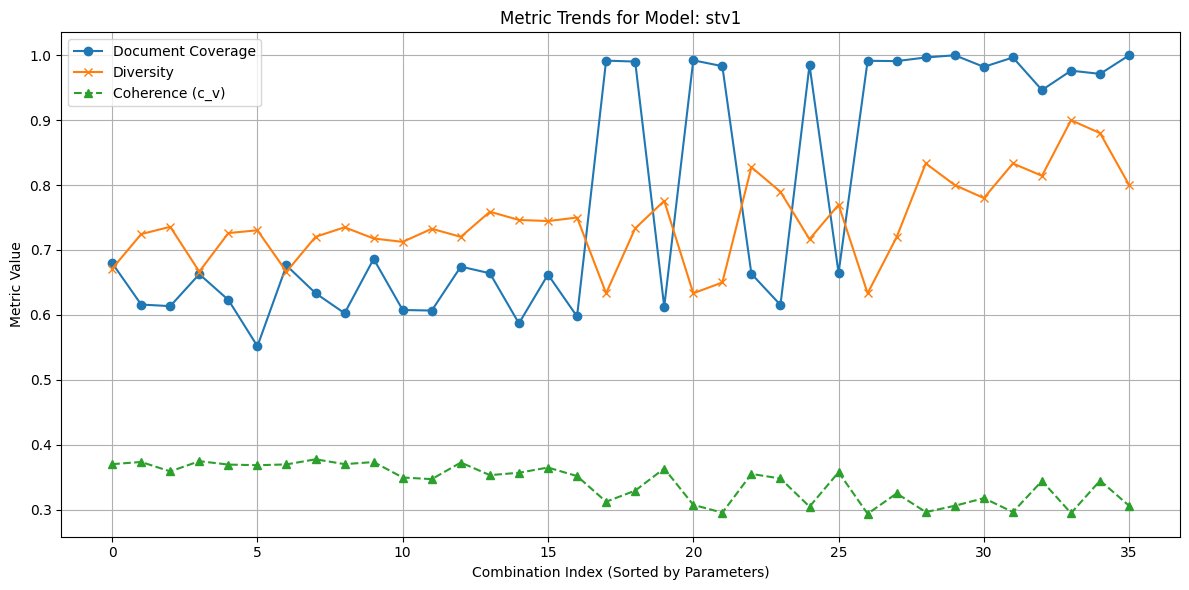

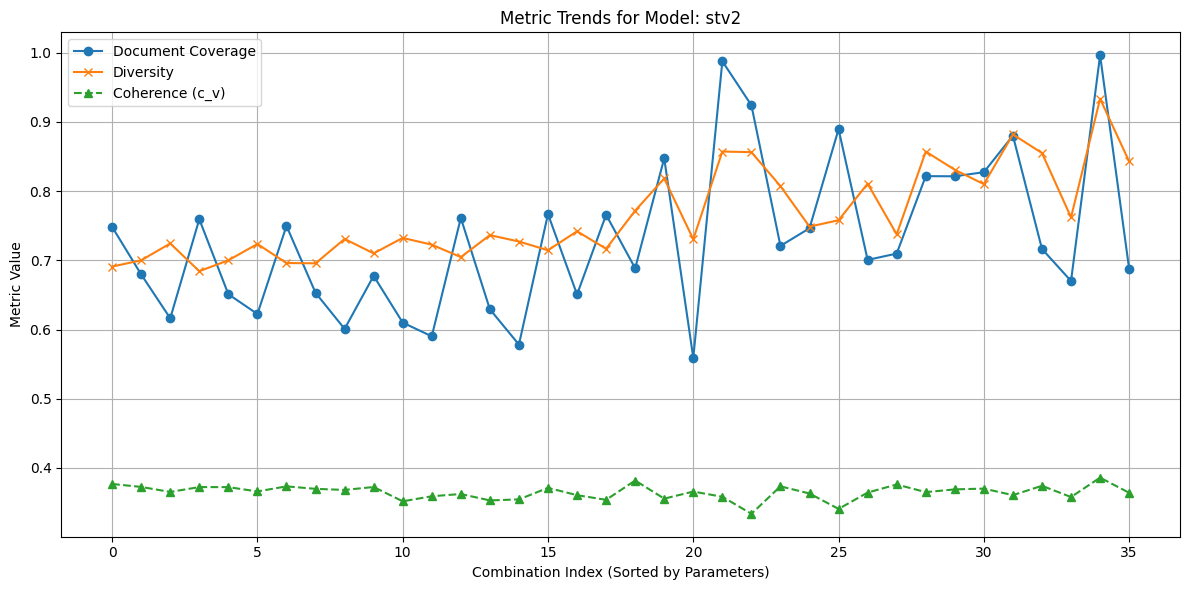

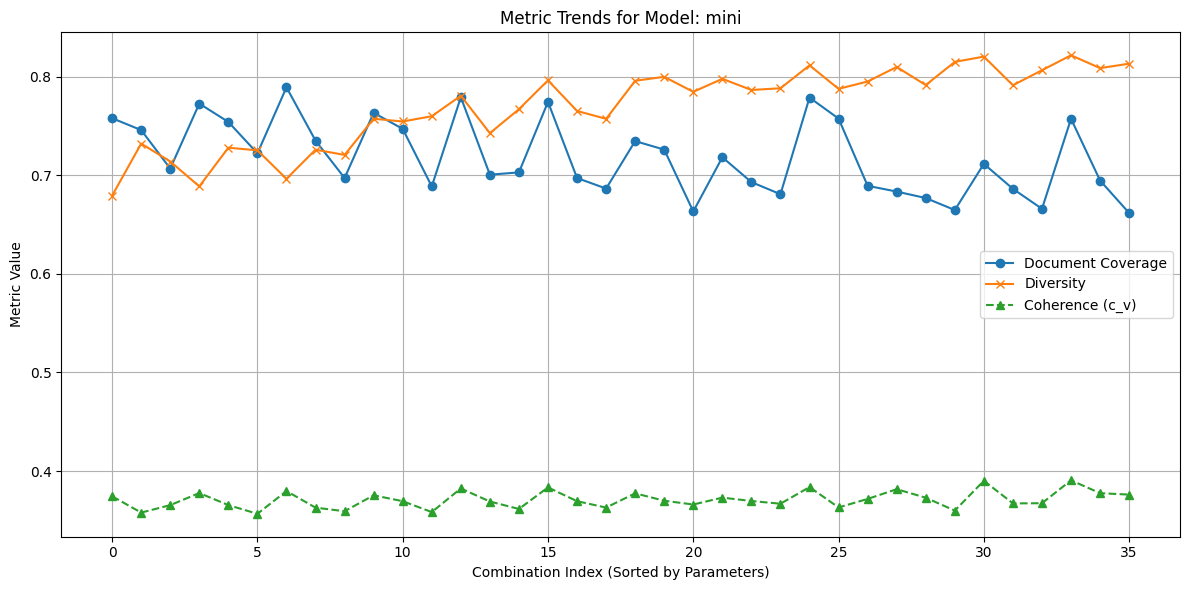

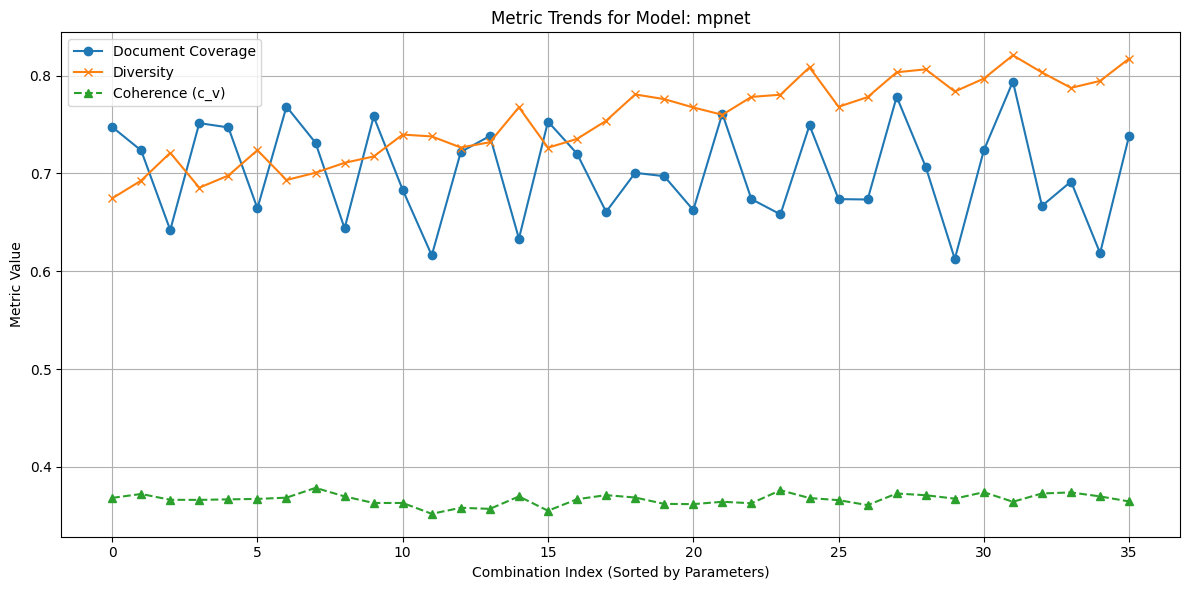

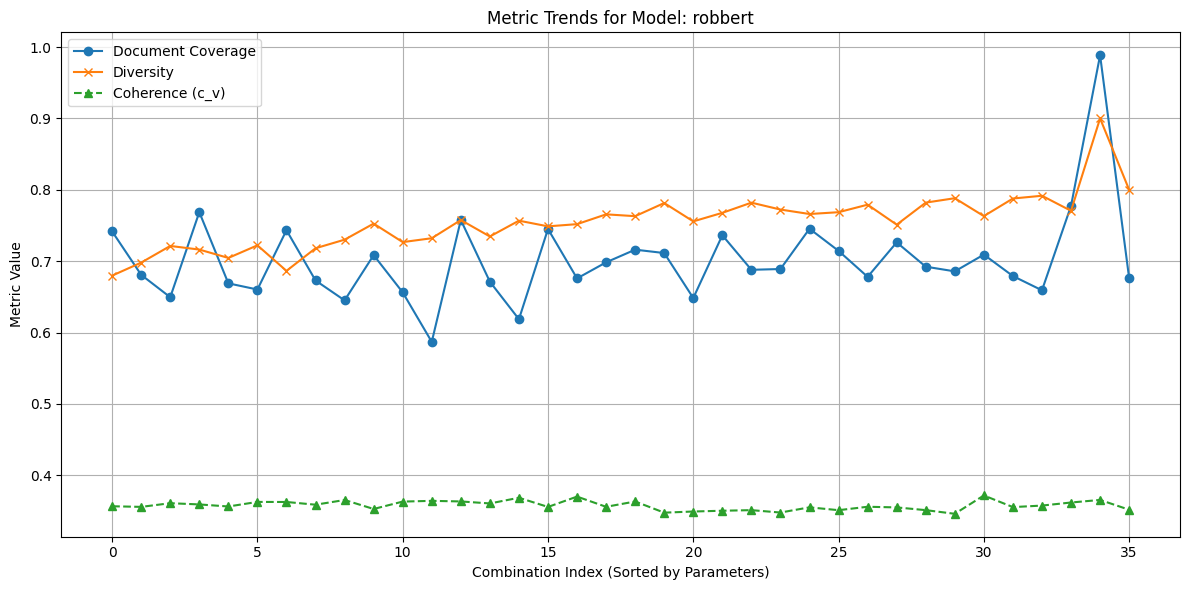

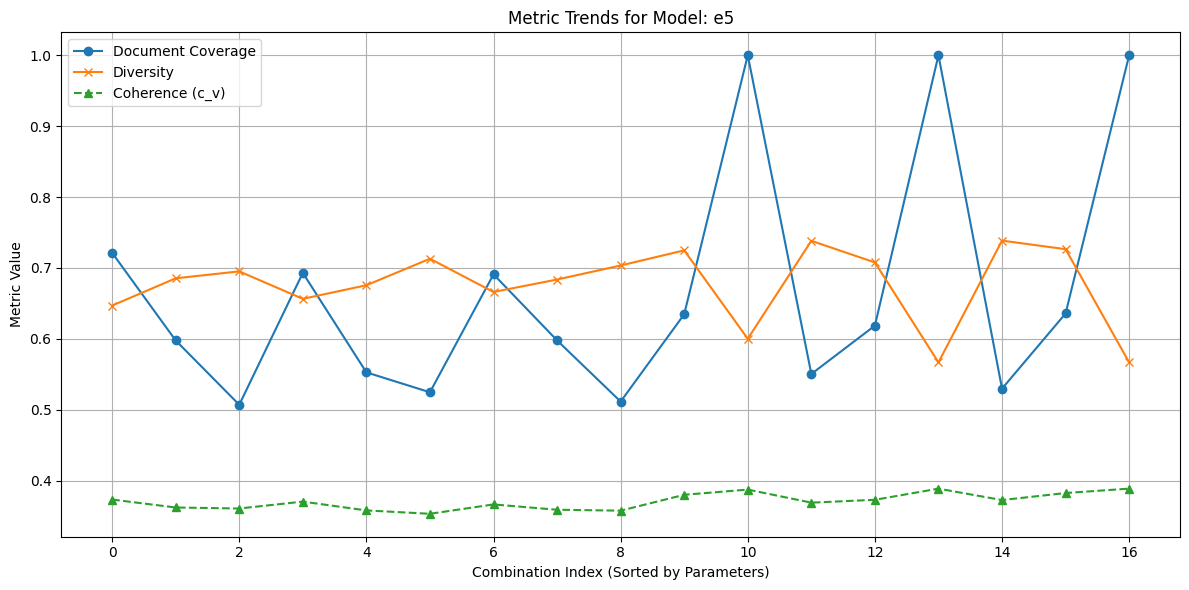

In [32]:
import matplotlib.pyplot as plt
import pandas as pd
df = df_coarse
# Assume df is your main dataframe
models = df['model_name'].unique()

for model in models:
    df_model = df[df['model_name'] == model]
    
    # Sort by parameters to reveal trends
    df_model_sorted = df_model.sort_values(
        by=["min_cluster_size", "n_components", "n_neighbors"]
    ).reset_index(drop=True)
    
    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(df_model_sorted.index, df_model_sorted['document_coverage'], label='Document Coverage', marker='o')
    plt.plot(df_model_sorted.index, df_model_sorted['diversity_score'], label='Diversity', marker='x')
    plt.plot(df_model_sorted.index, df_model_sorted['c_v_score'], label='Coherence (c_v)', linestyle='--', marker='^')

    plt.title(f'Metric Trends for Model: {model}')
    plt.xlabel('Combination Index (Sorted by Parameters)')
    plt.ylabel('Metric Value')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [19]:
'''
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic

metrics_vs_min_cluster_size = defaultdict(dict)
avg_topic_similarities = defaultdict(dict)
model_per_topic_similarities = defaultdict(dict)


for name, embedding_model, embeddings in models_and_embeddings:

    # search over min_cluster_size
    for size in min_cluster_sizes:
        topic_model = BERTopic(**bertopic_settings)
        topic_model.hdbscan_model = HDBSCAN(min_cluster_size=size, metric='euclidean', cluster_selection_method='eom', prediction_data=False)

        print(f"Tuning model: {name} at min_cluster_size {size}")

        topics, probs = topic_model.fit_transform(sentences, embeddings)
        top_words = get_top_words(topic_model, top_n=10)

        print(f"Metrics of {name} at min_cluster_size {size}:")
        
        #diversity_score = get_topic_diversity(top_words)
        #print(f"Diversity score: {diversity_score}")

        weighted_sim, unweighted_sim, topic_sim_dict = get_intra_topic_similarity(
            topic_model, sentences, embeddings
        )
        print(f"Average embedding cosine similarity weighted: {weighted_sim}, unweighted: {unweighted_sim}")
        #outlier_proportion = get_outlier_proportion(topic_model)
        #nr_topics = get_nr_topics(topic_model)
        
        #print(f"Outlier proportion: {outlier_proportion}")
        #print(f"Number of topics: {nr_topics}")
        #print(" ")

        #metrics_vs_min_cluster_size[(name, "min_cluster_size", size)]["min_cluster_size"] = size
        #metrics_vs_min_cluster_size[(name, "min_cluster_size", size)]["diversity_score"] = diversity_score
        #metrics_vs_min_cluster_size[(name, "min_cluster_size", size)]["weighted_avg_sim"] = weighted_sim
        #metrics_vs_min_cluster_size[(name, "min_cluster_size", size)]["unweighted_avg_sim"] = unweighted_sim
        #model_per_topic_similarities[(name, "min_cluster_size", size)]["per_topic_similarities"] = topic_sim_dict
        #metrics_vs_min_cluster_size[(name, "min_cluster_size", size)]["outlier proportion"] = outlier_proportion
        #metrics_vs_min_cluster_size[(name, "min_cluster_size", size)]["number of topics"] = nr_topics
'''    

'\nfor name, embedding_model, embeddings in models_and_embeddings:\n\n    # search over min_cluster_size\n    for size in min_cluster_sizes:\n        topic_model = BERTopic(**bertopic_settings)\n        topic_model.hdbscan_model = HDBSCAN(min_cluster_size=size, metric=\'euclidean\', cluster_selection_method=\'eom\', prediction_data=False)\n\n        print(f"Tuning model: {name} at min_cluster_size {size}")\n\n        topics, probs = topic_model.fit_transform(sentences, embeddings)\n        top_words = get_top_words(topic_model, top_n=10)\n\n        print(f"Metrics of {name} at min_cluster_size {size}:")\n        \n        #diversity_score = get_topic_diversity(top_words)\n        #print(f"Diversity score: {diversity_score}")\n\n        weighted_sim, unweighted_sim, topic_sim_dict = get_intra_topic_similarity(\n            topic_model, sentences, embeddings\n        )\n        print(f"Average embedding cosine similarity weighted: {weighted_sim}, unweighted: {unweighted_sim}")\n        #

In [20]:
# save the results

#import pickle
#import os

# Define the path where you want to save the files
#save_path = "/workspace/persistent/mijnidbcoachnlp/new_analysis/results"
#os.makedirs(save_path, exist_ok=True)

# Save the metrics_vs_parameter_results dictionary
#with open(os.path.join(save_path, "metrics_vs_parameter_results.pkl"), "wb") as f:
    #pickle.dump(metrics_vs_parameter_results, f)

# Save the parameter_intro_topics_similarities dictionary
#with open(os.path.join(save_path, "avg_topic_similarities.pkl"), "wb") as f:
    #pickle.dump(avg_topic_similarities, f)

# Save the parameter_intro_topics_similarities dictionary
#with open(os.path.join(save_path, "model_per_topic_similarities.pkl"), "wb") as f:
    #pickle.dump(model_per_topic_similarities, f)

#print("Dictionaries saved successfully.")


In [20]:
# load the results of trends over min_cluster_size
import pickle
import os

# Define the path where the files are saved
save_path = "/workspace/persistent/mijnidbcoachnlp/new_analysis/results"

# Load the metrics_vs_parameter_results dictionary
with open(os.path.join(save_path, "metrics_vs_min_cluster_size.pkl"), "rb") as f:
    metrics_vs_min_cluster_size = pickle.load(f)

with open(os.path.join(save_path, "avg_topic_similarities_over_min_cluster_size.pkl"), "rb") as f:
    avg_topic_similarities_over_min_cluster_size = pickle.load(f)

# Optional: Check what was loaded
print("Loaded metrics_vs_parameter_results keys:", list(metrics_vs_min_cluster_size.keys()))
print("Loaded avg_topic_similarities keys:", list(avg_topic_similarities_over_min_cluster_size.keys()))

Loaded metrics_vs_parameter_results keys: [('stv1', 'min_cluster_size', 5), ('stv1', 'min_cluster_size', 10), ('stv1', 'min_cluster_size', 15), ('stv1', 'min_cluster_size', 20), ('stv1', 'min_cluster_size', 25), ('stv1', 'min_cluster_size', 30), ('stv1', 'min_cluster_size', 35), ('stv2', 'min_cluster_size', 5), ('stv2', 'min_cluster_size', 10), ('stv2', 'min_cluster_size', 15), ('stv2', 'min_cluster_size', 20), ('stv2', 'min_cluster_size', 25), ('stv2', 'min_cluster_size', 30), ('stv2', 'min_cluster_size', 35), ('mini', 'min_cluster_size', 5), ('mini', 'min_cluster_size', 10), ('mini', 'min_cluster_size', 15), ('mini', 'min_cluster_size', 20), ('mini', 'min_cluster_size', 25), ('mini', 'min_cluster_size', 30), ('mini', 'min_cluster_size', 35), ('mpnet', 'min_cluster_size', 5), ('mpnet', 'min_cluster_size', 10), ('mpnet', 'min_cluster_size', 15), ('mpnet', 'min_cluster_size', 20), ('mpnet', 'min_cluster_size', 25), ('mpnet', 'min_cluster_size', 30), ('mpnet', 'min_cluster_size', 35), ('

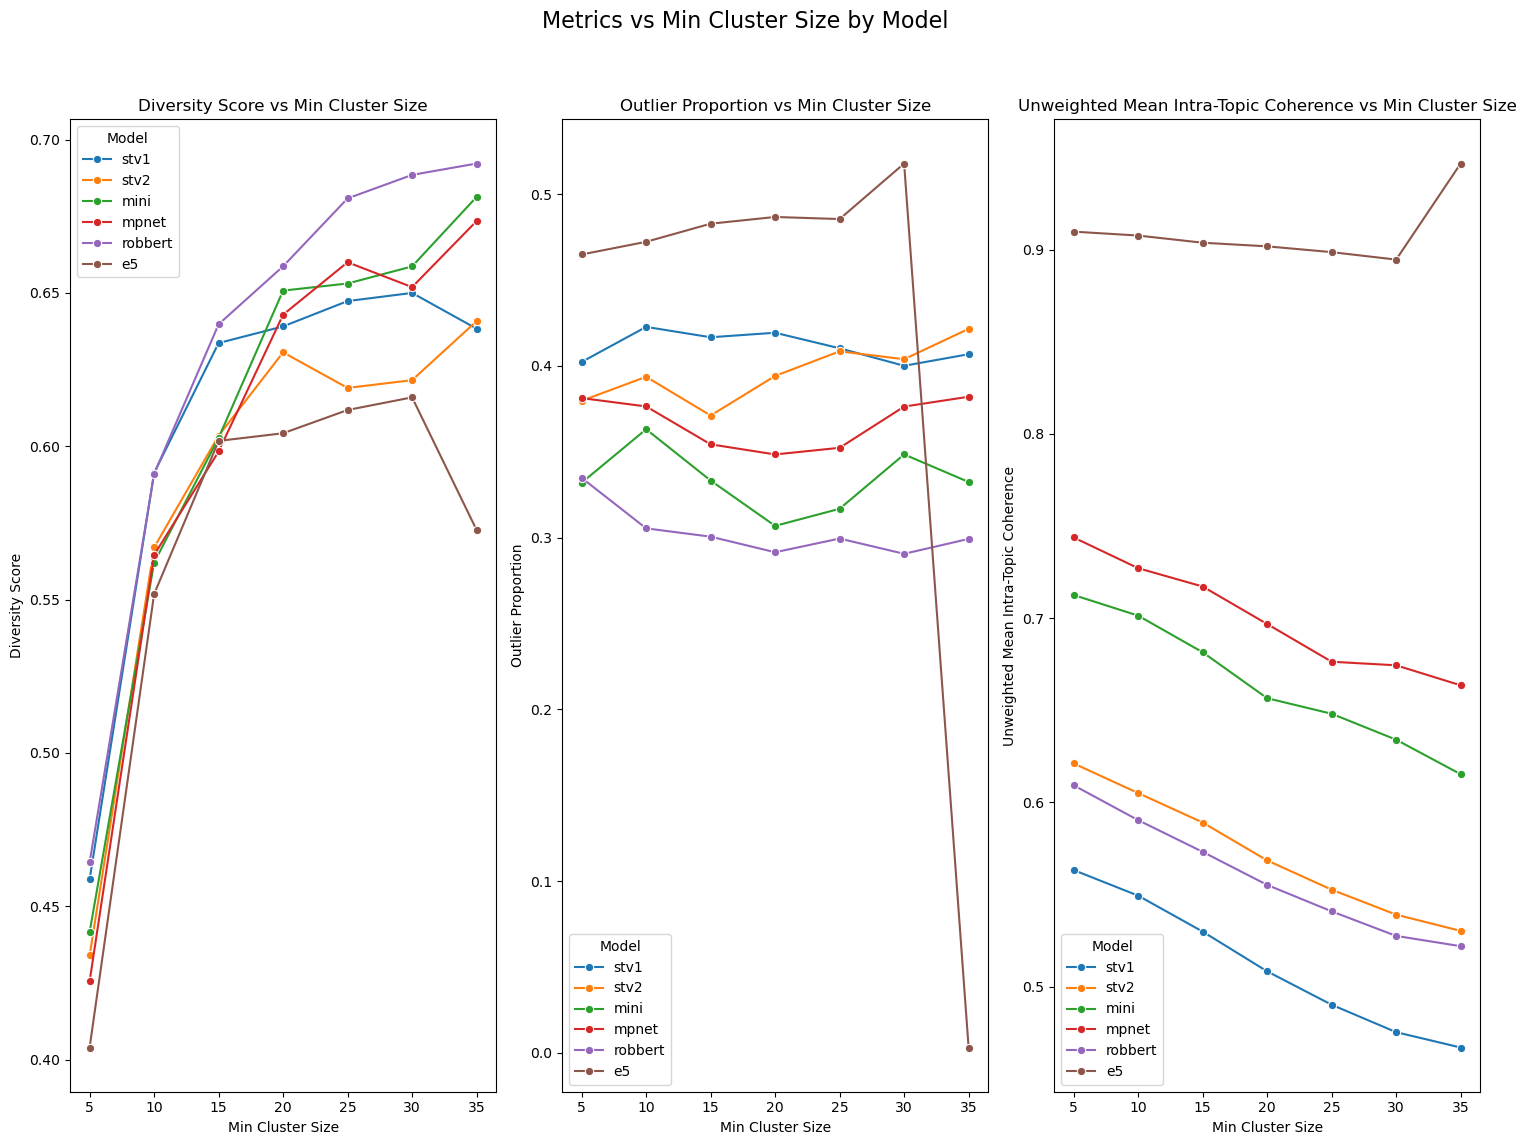

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load aggregate metrics
df = pd.read_csv("/workspace/persistent/mijnidbcoachnlp/new_analysis/results/model_parameters_vs_min_cluster_size.csv", index_col=0)

# Filter for min_cluster_size parameter only
df_cluster_size = df[df["Parameter"] == "min_cluster_size"]

# Create 4x1 subplots
fig, axes = plt.subplots(4, 1, figsize=(15, 16))
fig.suptitle('Metrics vs Min Cluster Size by Model', fontsize=18)

# Plot 1: Diversity Score
sns.lineplot(data=df_cluster_size, x="Parameter_Value", y="diversity_score", 
             hue="Model", marker="o", ax=axes[0])
axes[0].set_title('Diversity Score vs Min Cluster Size')
axes[0].set_xlabel('Min Cluster Size')
axes[0].set_ylabel('Diversity Score')

# Plot 2: Outlier Proportion
sns.lineplot(data=df_cluster_size, x="Parameter_Value", y="outlier proportion", 
             hue="Model", marker="o", ax=axes[1])
axes[1].set_title('Outlier Proportion vs Min Cluster Size')
axes[1].set_xlabel('Min Cluster Size')
axes[1].set_ylabel('Outlier Proportion')

# Plot 3: Unweighted Avg Similarity
sns.lineplot(data=df_cluster_size, x="Parameter_Value", y="unweighted_avg_sim", 
             hue="Model", marker="o", ax=axes[2])
axes[2].set_title('Unweighted Mean Intra-Topic Coherence vs Min Cluster Size')
axes[2].set_xlabel('Min Cluster Size')
axes[2].set_ylabel('Unweighted Mean Coherence')

# Plot 4: Per-topic Coherence Boxplot
sns.boxplot(data=df_topic_scores, x="Parameter_Value", y="Coherence", hue="Model", ax=axes[3])
axes[3].set_title('Per-Topic Coherence Score Distribution')
axes[3].set_xlabel('Min Cluster Size')
axes[3].set_ylabel('Per-Topic Coherence')

# Optional: improve layout
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()



In [30]:
# save the flattened results data
#df.to_csv("/workspace/persistent/mijnidbcoachnlp/new_analysis/results/model_parameters_vs_min_cluster_size.csv")

#### Results for GROW Science Day

In [24]:
'''
from bertopic import BERTopic

embedding_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
embeddings =  np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings/embeddings_st_miniL12v2_sentence_placeholder.npy")

topic_model = BERTopic(**bertopic_settings)
topic_model.hdbscan_model = HDBSCAN(min_cluster_size=25, metric='euclidean', cluster_selection_method='eom', prediction_data=False)
topic_model.umap_model = UMAP(n_neighbors=15, n_components=6, min_dist=0.0, metric='cosine', random_state=42)
topics, probs = topic_model.fit_transform(sentences, embeddings)

'''

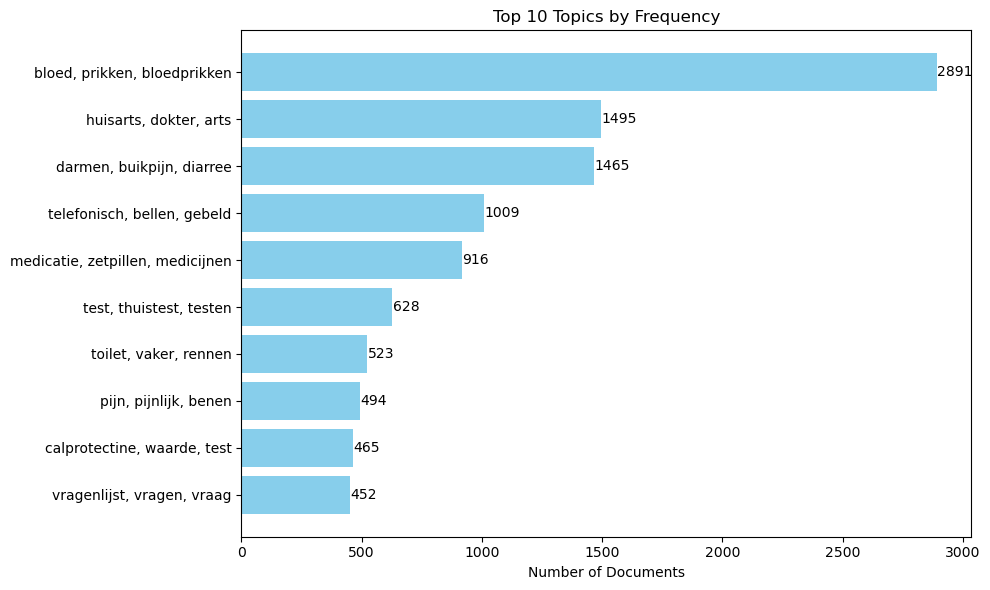

In [31]:
'''
import matplotlib.pyplot as plt

# Get topic info
topic_info = topic_model.get_topic_info()

# Exclude outlier topic -1 and get top 10 topics
top_10 = topic_info[topic_info.Topic != -1].head(10)

# Prepare labels: "Topic #ID: word1, word2, word3"
labels = [f"{', '.join(row['Representation'][:3])}" for _, row in top_10.iterrows()]
frequencies = top_10["Count"].values

# Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(labels, frequencies, color="skyblue")
plt.xlabel("Number of Documents")
plt.title("Top 10 Topics by Frequency")
plt.gca().invert_yaxis()  # Highest at the top

# Optional: Add counts next to bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 2, bar.get_y() + bar.get_height()/2,
             f'{int(width)}', va='center')

plt.tight_layout()
plt.show()
'''

#### 3.2.2. Diversity over n_components at min_cluster_size = 20

In [51]:
'''
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.representation import KeyBERTInspired

metrics_vs_n_components = defaultdict(dict)
avg_topic_similarities = defaultdict(dict)
model_per_topic_similarities = defaultdict(dict)
for name, embedding_model, embeddings in models_and_embeddings:
    

    # search over min_cluster_size
    for n_components in range_n_components:
        # configure the base settings
        topic_model = BERTopic(**bertopic_settings)
        topic_model.hdbscan_model = HDBSCAN(min_cluster_size=20, metric='euclidean', cluster_selection_method='eom', prediction_data=False)

        topic_model.umap_model = UMAP(n_neighbors=15, n_components=n_components, min_dist=0.0, metric='cosine', random_state=42)

        print(f"Tuning model: {name} at n_components {n_components}")

        topics, probs = topic_model.fit_transform(sentences, embeddings)
        top_words = get_top_words(topic_model, top_n=10) 
        diversity_score = get_topic_diversity(top_words)
        print(f"The diversity score of model {name} at n_componnet {n_components} is {diversity_score}")
        
        weighted_sim, unweighted_sim, topic_sim_dict = get_intra_topic_similarity(
            topic_model, sentences, embeddings
        )
        print(f"Average embedding cosine similarity weighted: {weighted_sim}, unweighted: {unweighted_sim}")
        outlier_proportion = get_outlier_proportion(topic_model)
        nr_topics = get_nr_topics(topic_model)
        
        print(f"Outlier proportion: {outlier_proportion}")
        print(f"Number of topics: {nr_topics}")
        print(" ")

        metrics_vs_parameter_results[(name, "n_components", n_components)]["n_components"] = n_components
        metrics_vs_parameter_results[(name, "n_components", n_components)]["diversity_score"] = diversity_score
        avg_topic_similarities[(name, "n_components", n_components)]["weighted_avg_sim"] = weighted_sim
        avg_topic_similarities[(name, "n_components", n_components)]["unweighted_avg_sim"] = unweighted_sim
        model_per_topic_similarities[(name, "n_components", n_components)]["per_topic_similarities"] = topic_sim_dict
        metrics_vs_parameter_results[(name, "n_components", n_components)]["outlier proportion"] = outlier_proportion
        metrics_vs_parameter_results[(name, "n_components", n_components)]["number of topics"] = nr_topics
'''

Tuning model: stv1 at n_components 5
The diversity score of model stv1 at n_componnet 5 is 0.6390756302521008
Average embedding cosine similarity weighted: 0.43449709474903153, unweighted: 0.508339524269104
Outlier proportion: 0.41924657700819573
Number of topics: 238
 
Tuning model: stv1 at n_components 6
The diversity score of model stv1 at n_componnet 6 is 0.6563318777292576
Average embedding cosine similarity weighted: 0.4261500874507386, unweighted: 0.5098806619644165
Outlier proportion: 0.40137162868746806
Number of topics: 229
 
Tuning model: stv1 at n_components 7
The diversity score of model stv1 at n_componnet 7 is 0.6362869198312237
Average embedding cosine similarity weighted: 0.4323286706692786, unweighted: 0.5163348317146301
Outlier proportion: 0.4164011770714268
Number of topics: 237
 
Tuning model: stv1 at n_components 8
The diversity score of model stv1 at n_componnet 8 is 0.6489626556016598
Average embedding cosine similarity weighted: 0.4337235665789815, unweighted: 

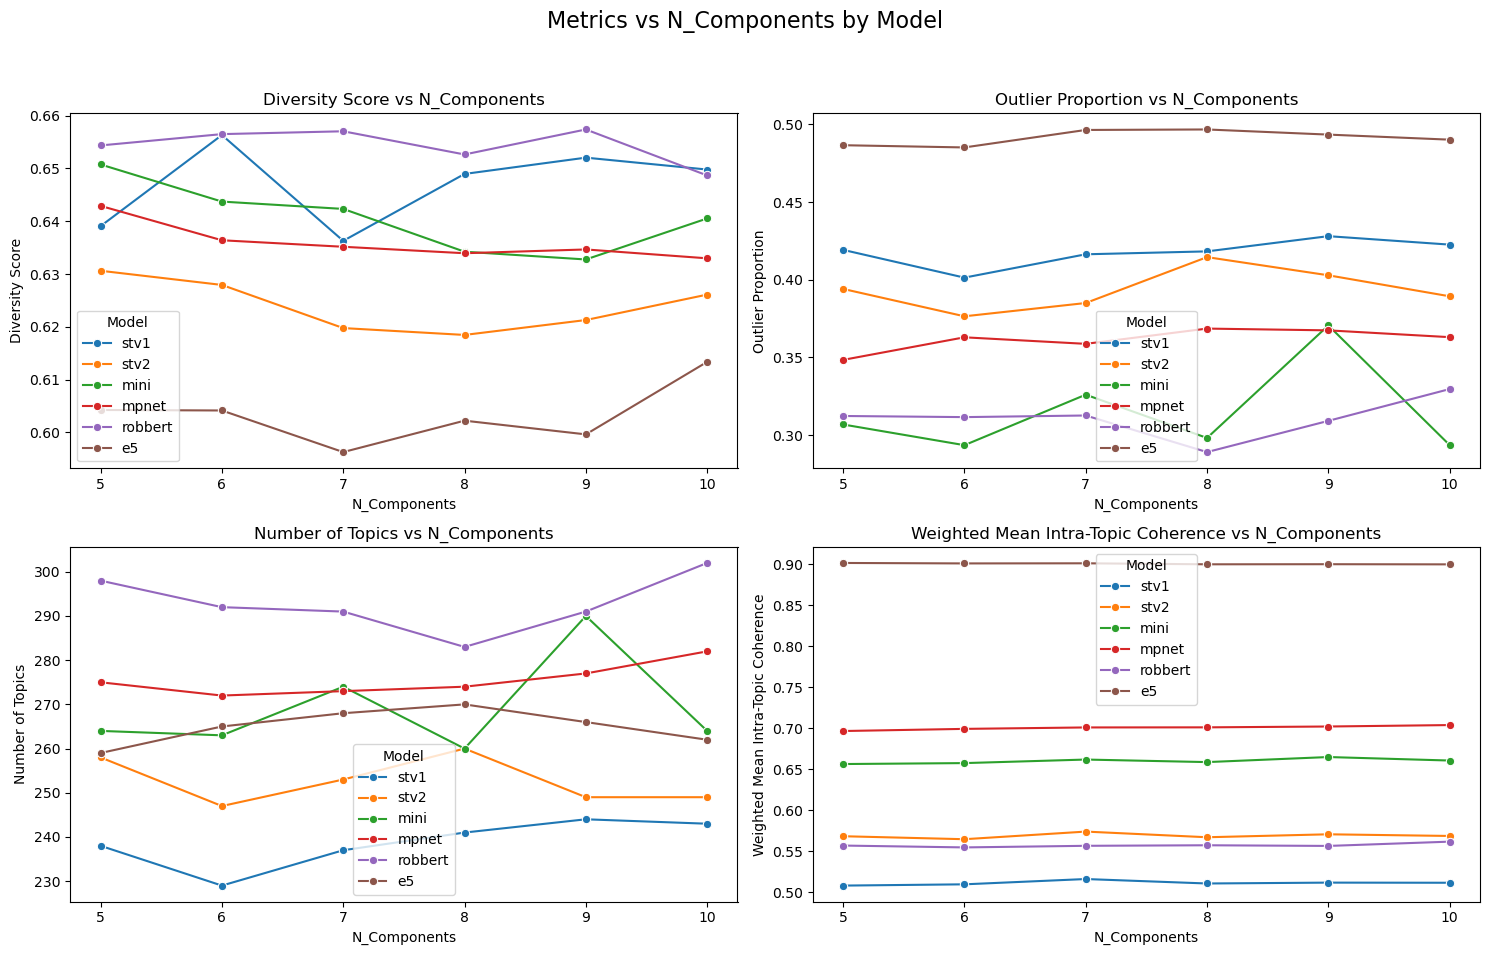

In [53]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#data = []

# Start by building a row for each entry in the first dictionary
#for key, metrics in metrics_vs_parameter_results.items():
    #row = {
        #"Model": key[0],
        #"Parameter": key[1],
        #"Parameter_Value": key[2],
        #**metrics
    #}

    # Merge in the metrics from the second dict if the key exists
    #if key in avg_topic_similarities:
        #row.update(avg_topic_similarities[key])

    #data.append(row)

df = pd.read_csv(os.path.join(save_path, "model_parameters_vs_n_components.csv"), index_col=0)

# Filter for min_cluster_size parameter only
df_cluster_size = df[df["Parameter"] == "n_components"]

# Create subplots for different metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Metrics vs N_Components by Model', fontsize=16)

# Plot 1: Diversity Score
sns.lineplot(data=df_cluster_size, x="Parameter_Value", y="diversity_score", 
             hue="Model", marker="o", ax=axes[0, 0])
axes[0, 0].set_title('Diversity Score vs N_Components')
axes[0, 0].set_xlabel('N_Components')
axes[0, 0].set_ylabel('Diversity Score')

# Plot 2: Outlier Proportion
sns.lineplot(data=df_cluster_size, x="Parameter_Value", y="outlier proportion", 
             hue="Model", marker="o", ax=axes[0, 1])
axes[0, 1].set_title('Outlier Proportion vs N_Components')
axes[0, 1].set_xlabel('N_Components')
axes[0, 1].set_ylabel('Outlier Proportion')

# Plot 3: Number of Topics
sns.lineplot(data=df_cluster_size, x="Parameter_Value", y="number of topics", 
             hue="Model", marker="o", ax=axes[1, 1])
axes[1, 1].set_title('Number of Topics vs Min Cluster Size')
axes[1, 1].set_xlabel('Min Cluster Size')
axes[1, 1].set_ylabel('Number of Topics')

# Plot 4: Unweighted Mean Intra-Topic Coherence
sns.lineplot(data=df_cluster_size, x="Parameter_Value", y="unweighted_avg_sim", 
             hue="Model", marker="o", ax=axes[1, 0])
axes[1, 0].set_title('Unweighted Mean Intra-Topic Coherence vs Min Cluster Size')
axes[1, 0].set_xlabel('Min Cluster Size')
axes[1, 0].set_ylabel('Weighted Mean Intra-Topic Coherence')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [54]:
#df.to_csv("/workspace/persistent/mijnidbcoachnlp/new_analysis/results/model_parameters_vs_n_components.csv")

In [21]:
# load the saved results data
df_n_components = pd.read_csv(os.path.join(save_path, "model_parameters_vs_n_components.csv"), index_col=0)

#### 3.2.3. Observe trends of diversity over n_neighbors

In [27]:
'''
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.representation import KeyBERTInspired

metrics_vs_n_neighbors = defaultdict(dict)
model_per_topic_similarities_n_neighbors = defaultdict(dict)

from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.representation import KeyBERTInspired

# Shared settings (avoid code duplication)
bertopic_settings = {
    "umap_model": UMAP(n_neighbors=15, n_components=6, min_dist=0.0, metric='cosine', random_state=42), # fixed random_state for reproducibility
    "hdbscan_model": HDBSCAN(min_cluster_size=20, metric='euclidean', cluster_selection_method='eom', prediction_data=False),
    "vectorizer_model": CountVectorizer(stop_words=dutch_stopwords, min_df=2, ngram_range=(1, 1), token_pattern=r'\b[a-zA-Z]{3,}\b'),
    "calculate_probabilities": False,
    "verbose": False
    #"representation_model": { 
    #    "KeyBERTInspired": KeyBERTInspired()
        #...
    #}
}

for name, embedding_model, embeddings in models_and_embeddings:
    

    # search over min_cluster_size
    for n_neighbors in range_n_neighbors:
        # configure the base settings
        topic_model = BERTopic(**bertopic_settings)
        topic_model.umap_model = UMAP(n_neighbors=n_neighbors, n_components=6, min_dist=0.0, metric='cosine', random_state=42)

        print(f"Tuning model: {name} at n_neighbors {n_neighbors}")

        topics, probs = topic_model.fit_transform(sentences, embeddings)
        top_words = get_top_words(topic_model, top_n=10) 
        diversity_score = get_topic_diversity(top_words)
        print(f"The diversity score of model {name} at n_neighbors {n_neighbors} is {diversity_score}")
        
        weighted_sim, unweighted_sim, topic_sim_dict = get_intra_topic_similarity(
            topic_model, sentences, embeddings
        )
        print(f"Average embedding cosine similarity weighted: {weighted_sim}, unweighted: {unweighted_sim}")
        outlier_proportion = get_outlier_proportion(topic_model)
        nr_topics = get_nr_topics(topic_model)
        
        print(f"Outlier proportion: {outlier_proportion}")
        print(f"Number of topics: {nr_topics}")
        print(" ")

        metrics_vs_n_neighbors[(name, "n_neighbors", n_neighbors)]["n_neighbors"] = n_neighbors
        metrics_vs_n_neighbors[(name, "n_neighbors", n_neighbors)]["diversity_score"] = diversity_score
        metrics_vs_n_neighbors[(name, "n_neighbors", n_neighbors)]["weighted_avg_sim"] = weighted_sim
        metrics_vs_n_neighbors[(name, "n_neighbors", n_neighbors)]["unweighted_avg_sim"] = unweighted_sim
        model_per_topic_similarities[(name, "n_neighbors", n_neighbors)]["per_topic_similarities"] = topic_sim_dict
        metrics_vs_n_neighbors[(name, "n_neighbors", n_neighbors)]["outlier proportion"] = outlier_proportion
        metrics_vs_n_neighbors[(name, "n_neighbors", n_neighbors)]["number of topics"] = nr_topics
'''

Tuning model: stv1 at n_neighbors 5
The diversity score of model stv1 at n_neighbors 5 is 0.6438235294117647
Average embedding cosine similarity weighted: 0.4167010877700939, unweighted: 0.4618956744670868
Outlier proportion: 0.3769546924779299
Number of topics: 340
 
Tuning model: stv1 at n_neighbors 10
The diversity score of model stv1 at n_neighbors 10 is 0.6511363636363636
Average embedding cosine similarity weighted: 0.43163218424871896, unweighted: 0.49877849221229553
Outlier proportion: 0.3969211313504706
Number of topics: 264
 
Tuning model: stv1 at n_neighbors 15
The diversity score of model stv1 at n_neighbors 15 is 0.6563318777292576
Average embedding cosine similarity weighted: 0.4261500874507386, unweighted: 0.5098806619644165
Outlier proportion: 0.40137162868746806
Number of topics: 229
 
Tuning model: stv1 at n_neighbors 20
The diversity score of model stv1 at n_neighbors 20 is 0.6357758620689655
Average embedding cosine similarity weighted: 0.44108524968679297, unweight

In [28]:
'''
import pickle
import os

# Define the path where you want to save the files
save_path = "/workspace/persistent/mijnidbcoachnlp/new_analysis/results"
#os.makedirs(save_path, exist_ok=True)


with open(os.path.join(save_path, "metrics_vs_n_neighbors.pkl"), "wb") as f:
    pickle.dump(metrics_vs_n_neighbors, f)


# Save the parameter_intro_topics_similarities dictionary
with open(os.path.join(save_path, "model_per_topic_similarities_n_neighbors.pkl"), "wb") as f:
    pickle.dump(model_per_topic_similarities, f)

print("Dictionaries saved successfully.")
'''

Dictionaries saved successfully.


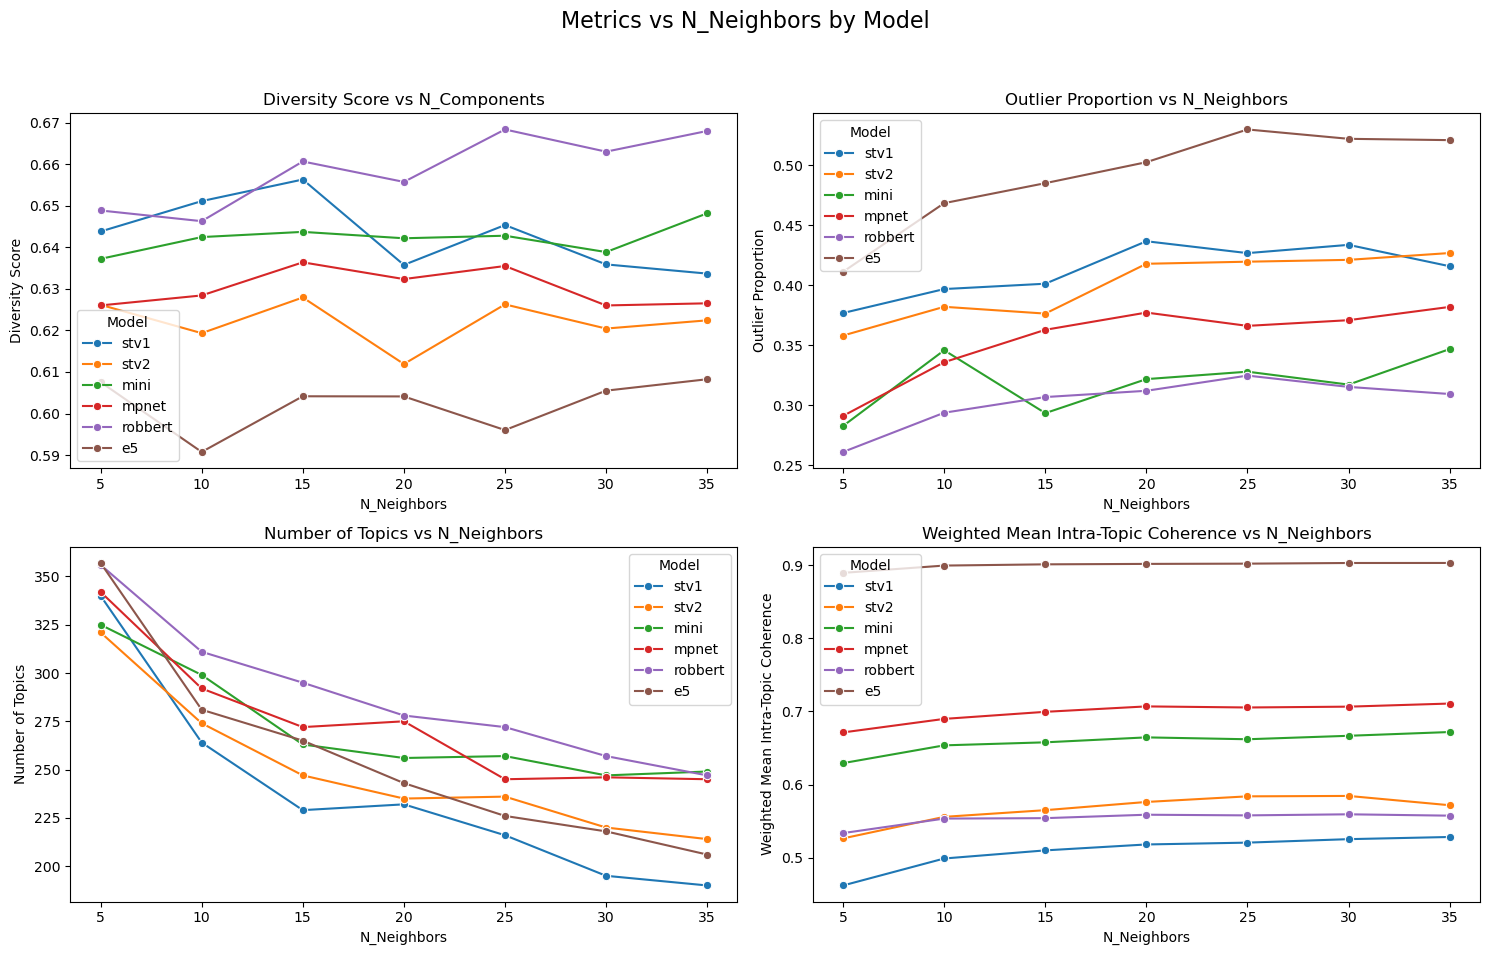

In [35]:
'''
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
data = []

for key, metrics in metrics_vs_n_neighbors.items():
    row = {
        "Model": key[0],
        "Parameter": key[1],
        "Parameter_Value": key[2],
        **metrics
    }
    data.append(row)  # <-- This line is necessary


df = pd.DataFrame(data)

# Filter for min_cluster_size parameter only
df_cluster_size = df
# Create subplots for different metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Metrics vs N_Neighbors by Model', fontsize=16)

# Plot 1: Diversity Score
sns.lineplot(data=df_cluster_size, x="Parameter_Value", y="diversity_score", 
             hue="Model", marker="o", ax=axes[0, 0])
axes[0, 0].set_title('Diversity Score vs N_Components')
axes[0, 0].set_xlabel('N_Neighbors')
axes[0, 0].set_ylabel('Diversity Score')

# Plot 2: Outlier Proportion
sns.lineplot(data=df_cluster_size, x="Parameter_Value", y="outlier proportion", 
             hue="Model", marker="o", ax=axes[0, 1])
axes[0, 1].set_title('Outlier Proportion vs N_Neighbors')
axes[0, 1].set_xlabel('N_Neighbors')
axes[0, 1].set_ylabel('Outlier Proportion')

# Plot 3: Number of Topics
sns.lineplot(data=df_cluster_size, x="Parameter_Value", y="number of topics", 
             hue="Model", marker="o", ax=axes[1, 0])
axes[1, 0].set_title('Number of Topics vs N_Neighbors')
axes[1, 0].set_xlabel('N_Neighbors')
axes[1, 0].set_ylabel('Number of Topics')

# Plot 4: Unweighted Mean Intra-Topic Coherence
sns.lineplot(data=df_cluster_size, x="Parameter_Value", y="unweighted_avg_sim", 
             hue="Model", marker="o", ax=axes[1, 1])
axes[1, 1].set_title('Weighted Mean Intra-Topic Coherence vs N_Neighbors')
axes[1, 1].set_xlabel('N_Neighbors')
axes[1, 1].set_ylabel('Weighted Mean Intra-Topic Coherence')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [7]:
import os
import pickle

save_path = "/workspace/persistent/mijnidbcoachnlp/new_analysis/results"


with open(os.path.join(save_path, "metrics_vs_n_neighbors.pkl"), "rb") as f:
    metrics_vs_n_neighbors = pickle.load(f)

with open(os.path.join(save_path, "metrics_vs_min_cluster_size.pkl"), "rb") as f:
    metrics_vs_min_cluster_size = pickle.load(f)

In [25]:
import pandas as pd 

data = []

for key, metrics in metrics_vs_n_neighbors.items():
    row = {
        "Model": key[0],
        "Parameter": key[1],
        "Parameter_Value": key[2],
        **metrics
    }
    data.append(row)  # <-- This line is necessary

df_n_neighbors = pd.DataFrame(data)
df_n_neighbors = df_n_neighbors.drop(columns=["n_neighbors"])


In [21]:
df_min_cluster_size = pd.read_csv(os.path.join(save_path, "model_parameters_vs_min_cluster_size.csv"), index_col=0)
df_min_cluster_size = df_min_cluster_size.drop(columns=["min_cluster_size"])

df_min_cluster_size.head()

,Model,Parameter,Parameter_Value,diversity_score,outlier proportion,number of topics,weighted_avg_sim,unweighted_avg_sim
0,stv1,min_cluster_size,5,0.458804,0.402247,920,0.495222,0.563306
1,stv1,min_cluster_size,10,0.591332,0.422651,473,0.470171,0.549408
2,stv1,min_cluster_size,15,0.633657,0.416620,309,0.448442,0.529916
3,stv1,min_cluster_size,20,0.639076,0.419247,238,0.434497,0.508340
4,stv1,min_cluster_size,25,0.647340,0.410200,188,0.416380,0.490223


In [ ]:
filtered_df = df_min_cluster_size[(df_min_cluster_size['age'] >= 25) & (df['age'] <= 45)]


In [23]:
df_n_components = pd.read_csv(os.path.join(save_path, "model_parameters_vs_n_components.csv"), index_col=0)
df_n_components = df_n_components.drop(columns=["n_components"])

df_n_components.head()

,Model,Parameter,Parameter_Value,diversity_score,outlier proportion,number of topics,weighted_avg_sim,unweighted_avg_sim
0,stv1,n_components,5,0.639076,0.419247,238,0.434497,0.508340
1,stv1,n_components,6,0.656332,0.401372,229,0.426150,0.509881
2,stv1,n_components,7,0.636287,0.416401,237,0.432329,0.516335
3,stv1,n_components,8,0.648963,0.418274,241,0.433724,0.510903
4,stv1,n_components,9,0.652049,0.428075,244,0.437536,0.511961


In [28]:
df_min_cluster_size.columns

Index(['Model', 'Parameter', 'Parameter_Value', 'diversity_score',
       'outlier proportion', 'number of topics', 'weighted_avg_sim',
       'unweighted_avg_sim'],
      dtype='object')

In [29]:
new_order = ['Model', 'Parameter', 'Parameter_Value', 'diversity_score', 'outlier proportion', 
            'number of topics', 'weighted_avg_sim', 'unweighted_avg_sim']

df_n_neighbors = df_n_neighbors[new_order]
df_n_neighbors.head()



,Model,Parameter,Parameter_Value,diversity_score,outlier proportion,number of topics,weighted_avg_sim,unweighted_avg_sim
0,stv1,n_neighbors,5,0.643824,0.376955,340,0.416701,0.461896
1,stv1,n_neighbors,10,0.651136,0.396921,264,0.431632,0.498778
2,stv1,n_neighbors,15,0.656332,0.401372,229,0.426150,0.509881
3,stv1,n_neighbors,20,0.635776,0.436781,232,0.441085,0.517978
4,stv1,n_neighbors,25,0.645370,0.426883,216,0.426826,0.520483


In [38]:
df_filtered = df_n_neighbors[(df_n_neighbors['number of topics'] >= 100) & (df_n_neighbors['number of topics'] <= 250)]


In [40]:
df_filtered = df_filtered[(df_filtered['outlier proportion'] <= 0.4)]

In [41]:
df_filtered

,Model,Parameter,Parameter_Value,diversity_score,outlier proportion,number of topics,weighted_avg_sim,unweighted_avg_sim
9,stv2,n_neighbors,15,0.627935,0.376468,247,0.476936,0.564894
19,mini,n_neighbors,30,0.638866,0.317274,247,0.595214,0.666649
20,mini,n_neighbors,35,0.648193,0.346896,249,0.603393,0.671802
25,mpnet,n_neighbors,25,0.635510,0.366230,245,0.639325,0.705378
26,mpnet,n_neighbors,30,0.626016,0.370972,246,0.642178,0.706507
27,mpnet,n_neighbors,35,0.626531,0.382038,245,0.642270,0.710761
34,robbert,n_neighbors,35,0.668016,0.309419,247,0.519774,0.557380
